# Fine Tune on 100% data with 101 food classes


In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-07-08 15:51:39--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-07-08 15:51:40 (24.5 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [5]:
import warnings

warnings.filterwarnings("ignore")

from helper_functions import plot_loss_curves, compare_historys

## Get the Data from Tensorflow Datasets


In [6]:
import tensorflow_datasets as tfds

In [ ]:
(train_data, test_data), ds_info = tfds.load(
    name="food101",
    split=["train", "validation"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

In [7]:
import tensorflow as tf

train_size = tf.data.experimental.cardinality(train_data).numpy()
test_size = tf.data.experimental.cardinality(test_data).numpy()

print(f"Train size: {train_size}")
print(f"Test size: {test_size}")

Train size: 75750
Test size: 25250


In [8]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [9]:
classnames = ds_info.features["label"].names

In [10]:
import matplotlib.pyplot as plt
import random


def show_random_image(dataset=train_data, ds_info=ds_info, n=3):
    # Get class names from ds_info
    class_names = ds_info.features["label"].names

    plt.figure(figsize=(15, 5))

    # Shuffle a large buffer, then grab n examples
    for i, (image, label) in enumerate(dataset.shuffle(buffer_size=1000).take(n)):
        plt.subplot(1, n, i + 1)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(f"Class: {class_names[label.numpy()]}\nShape: {image.shape}")
        plt.axis(False)

    plt.show()

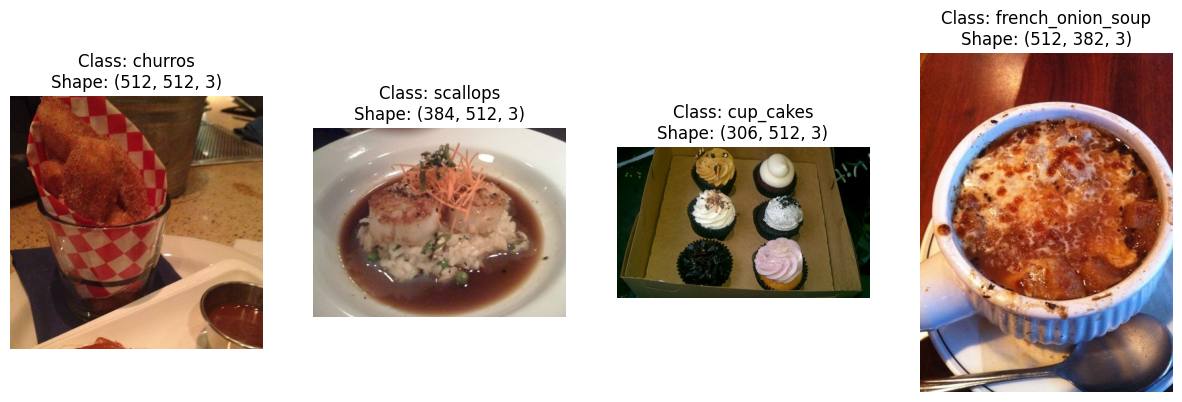

In [11]:
show_random_image(train_data, ds_info, n=4)

In [2]:
import tensorflow as tf

for image, label in train_data.take(1):
    print(image.shape, label.numpy())

tf.reduce_min(image), tf.reduce_max(image)

NameError: name 'train_data' is not defined

## Batch and prepare dataset


In [13]:
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'uint8' -> 'float32' and reshapes image to [img_shape, img_shape, color_channels]
    """
    image = tf.image.resize(image, [img_shape, img_shape])
    return (
        tf.cast(image, tf.float32),
        label,
    )  # return the tuple of (float32_imaage, label)

In [14]:
train_data = train_data.map(
    map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE
)
# shuffling train_data just to be sure
# but when loading the data it was already shuffled
train_data = (
    train_data.shuffle(buffer_size=1000)
    .batch(32)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_data = test_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# shuffling same as train data
test_data = (
    test_data.shuffle(buffer_size=1000).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [1]:
import matplotlib.pyplot as plt
import random


def show_random_image_with_batches(dataset=train_data, ds_info=ds_info, n=3):
    # Get class names from ds_info
    class_names = ds_info.features["label"].names

    # Grab a single shuffled batch
    for images, labels in dataset.shuffle(buffer_size=1000).take(1):
        plt.figure(figsize=(15, 5))

        # Pick n random indices from within the batch
        batch_size = images.shape[0]
        indices = random.sample(range(batch_size), min(n, batch_size))

        for i, idx in enumerate(indices):
            plt.subplot(1, n, i + 1)
            plt.imshow(images[idx].numpy().astype("uint8"))
            plt.title(
                f"Class: {class_names[labels[idx].numpy()]}\nShape: {images[idx].shape}"
            )
            plt.axis(False)

        plt.show()

NameError: name 'train_data' is not defined

In [16]:
show_random_image_with_batches(train_data, ds_info)
# all the images are not in (224, 224, 3) shape

: 

: 

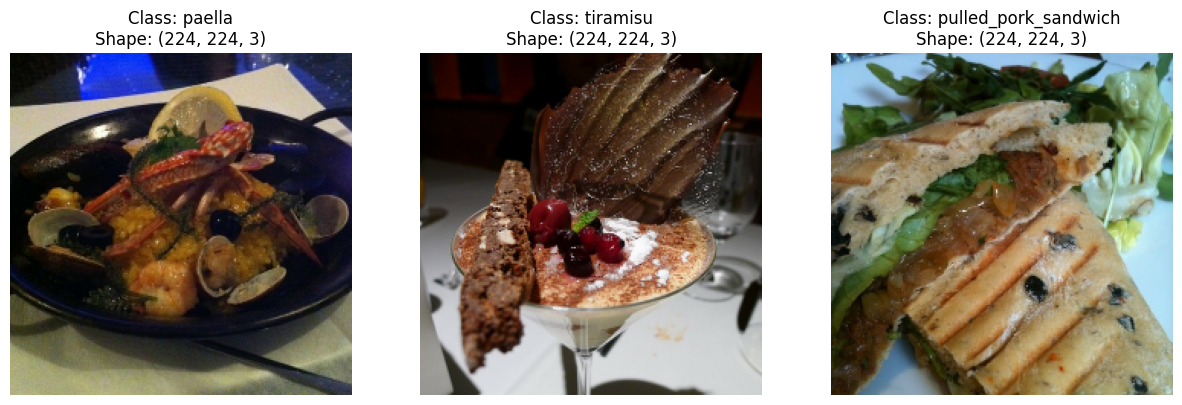

In [ ]:
show_random_image_with_batches(test_data, ds_info)
# all the images are not in (224, 224, 3) shape

In [ ]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

## Model Callbacks


In [ ]:
checkpoint_path = "model_checkpoint/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

## Mixed Precision


In [ ]:
# Mixed precision utilizes a combination of float32 and float16 data types to speed up model performance

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

## Training (Feature Extraction)


In [ ]:
input_shape = (224, 224, 3)

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=input_shape, name="input_layer")
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(
    len(classnames), activation="softmax", dtype=tf.float32
)(x)

model_1 = tf.keras.Model(inputs, outputs)

# compiling
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",  # label is in integer form, use sparse_categorical_cross_entropy
    metrics=["accuracy"],
)

# training
history_1 = model_1.fit(
    train_data,
    epochs=3,
    validation_data=test_data,
    validation_steps=(0.15 * len(test_data)),
    callbacks=[model_checkpoint, early_stopping],
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
  28/2368 ━━━━━━━━━━━━━━━━━━━━ 46:14 1s/step - accuracy: 0.0363 - loss: 4.6223

KeyboardInterrupt: 

In [ ]:
model_1.save("./feature_extracted_model.keras")

NameError: name 'model_1' is not defined

In [ ]:
results_1 = model_1.evaluate(test_data)

NameError: name 'model_1' is not defined

In [ ]:
model_2 = model_1

base_model = model_2.layers[2]
base_model.trainable = True

# refreeze every layer except the last 5
for layer in base_model.layers[:-10]:
    layer.trainable = False

model_2.compile(
    loss="sparse_categorical_crossentropy",  # use "sparse_categorical_crossentropy" if your labels are integers, not one-hot
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),  # during fine tuning lower the learning rate by 10x
    metrics=["accuracy"],
)

epochs = 3
fine_tune_epochs = epochs + 3

history_2 = model_2.fit(
    train_data,
    epochs=fine_tune_epochs,
    validation_data=test_data,
    validation_steps=(0.15 * len(test_data)),
    initial_epoch=history_1.epoch[-1],
)

In [ ]:
results_2 = model_2.evaluate(test_data)

In [ ]:
model_2.save("./fine_tuned_model.keras")

In [ ]:
compare_historys(history_1, history_2, initial_epochs=5)

## Ploting random results


In [ ]:
import random
import matplotlib.pyplot as plt

class_names = ds_info.features["label"].names


def pred_and_plot_random_image(model, dataset, class_names, ax):
    # 1. Grab one random batch, then pick one random image from it
    for images, labels in dataset.shuffle(buffer_size=1000).take(1):
        idx = random.randint(0, images.shape[0] - 1)
        img = images[idx]
        true_label = class_names[labels[idx].numpy()]

    # 2. Make prediction (model expects float32 [224,224,3], batch dim added)
    pred_probs = model.predict(tf.expand_dims(img, axis=0), verbose=0)
    pred_class = class_names[pred_probs.argmax()]
    conf_score = pred_probs.max()

    # 3. Normalize for display only (img is float32 [0,255] from your preprocessing)
    img_display = img / 255.0

    # 4. Plot onto the given axis
    ax.imshow(img_display)
    title_color = "green" if pred_class == true_label else "red"
    ax.set_title(
        f"Actual: {true_label}\nPred: {pred_class} ({conf_score:.2%})",
        color=title_color,
    )
    ax.axis(False)


# Create one figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax in axes:
    pred_and_plot_random_image(model_2, test_data, class_names, ax)

plt.tight_layout()
plt.show()

## Confusion Matrix


In [ ]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


def make_confusion_matrix(
    y_true,
    y_pred,
    classes=None,
    figsize=(10, 10),
    text_size=15,
    norm=False,
    savefig=False,
):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])

    ax.set(
        title="Confusion Matrix",
        xlabel="Predicted label",
        ylabel="True label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels,
    )

    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    plt.xticks(rotation=70, fontsize=text_size)
    plt.yticks(fontsize=text_size)

    threshold = (cm.max() + cm.min()) / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if norm:
            plt.text(
                j,
                i,
                f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size,
            )
        else:
            plt.text(
                j,
                i,
                f"{cm[i, j]}",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size,
            )

    if savefig:
        fig.savefig("confusion_matrix.png")

In [ ]:
# Get true labels (unbatch test_data to get all labels in order)
y_labels = []
for images, labels in test_data.unbatch():
    y_labels.append(labels.numpy())  # labels are already sparse integers, not one-hot

# Get class names from ds_info (not test_data.class_names, since this is a tfds dataset)
class_names = ds_info.features["label"].names

# Get predictions
pred_probs = model_2.predict(test_data, verbose=1)  # returns softmax probabilities
pred_classes = pred_probs.argmax(axis=1)

In [ ]:
make_confusion_matrix(
    y_true=y_labels,
    y_pred=pred_classes,
    classes=class_names,
    figsize=(40, 40),
    text_size=8,
)

## Classification Report and Bar Plot


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true=y_labels,
        y_pred=pred_classes,
    )
)

# plotting class no. and f1 score

class_names = ds_info.features[
    "label"
].names  # replaces test_data_10_percent.class_names

classification_report_dict = classification_report(
    y_labels, pred_classes, output_dict=True
)

class_f1_scores = {}

for class_name, metrics in classification_report_dict.items():
    if (
        class_name != "accuracy"
        and class_name != "macro avg"
        and class_name != "weighted avg"
    ):
        class_f1_scores[class_names[int(class_name)]] = metrics["f1-score"]

In [ ]:
import pandas as pd

f1_scores = pd.Series(class_f1_scores).sort_values(ascending=True)

In [ ]:
f1_scores.plot.bar(figsize=(40, 20))
plt.xticks(fontsize=15)
plt.show()